In [31]:
import numpy as np
import h5py as hp # biblioteka za manipulaciiju nad hdf fajlovima
import pandas as pd
import glob
import os
import illustris_python as il
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib import rc
from scipy.stats import pearsonr, spearmanr

In [33]:
GROUPCAT_DIR = "/Volumes/Tina/Milos/TNG100/group99"

In [45]:
files = sorted(glob.glob(os.path.join(GROUPCAT_DIR, "*.hdf5")))
with hp.File(files[0], "r") as data:
    print("Glavne grupe u fajlu:")
    print(list(data.keys()))

    print("\nHeader atributi:")
    for key in data["Header"].attrs.keys():
        print(key, "=", data["Header"].attrs[key])

    print("\nPolja u Group:")
    print(list(data["Group"].keys())[:30])

    print("\nPolja u Subhalo:")
    print(list(data["Subhalo"].keys())[:30])

Glavne grupe u fajlu:
['Config', 'Group', 'Header', 'IDs', 'Parameters', 'Subhalo']

Header atributi:
BoxSize = 75000.0
FlagDoubleprecision = 0
Git_commit = b'd203ec8b07c7e2bdda5f608aa0babea46d603699'
Git_date = b'Thu Apr 7 14:14:27 2016 +0200'
HubbleParam = 0.6774
Ngroups_ThisFile = 1
Ngroups_Total = 6291349
Nids_ThisFile = 11830481
Nids_Total = 5263038490
Nsubgroups_ThisFile = 17185
Nsubgroups_Total = 4371211
NumFiles = 448
Omega0 = 0.3089
OmegaLambda = 0.6911
Redshift = 2.220446049250313e-16
Time = 0.9999999999999998

Polja u Group:
['GroupBHMass', 'GroupBHMdot', 'GroupCM', 'GroupFirstSub', 'GroupGasMetalFractions', 'GroupGasMetallicity', 'GroupLen', 'GroupLenType', 'GroupMass', 'GroupMassType', 'GroupNsubs', 'GroupPos', 'GroupSFR', 'GroupStarMetalFractions', 'GroupStarMetallicity', 'GroupVel', 'GroupWindMass', 'Group_M_Crit200', 'Group_M_Crit500', 'Group_M_Mean200', 'Group_M_TopHat200', 'Group_R_Crit200', 'Group_R_Crit500', 'Group_R_Mean200', 'Group_R_TopHat200']

Polja u Subhalo:


In [49]:
SNAP = 99
# Pragovi za podelu okruženja
FIELD_GROUP_LIMIT = 5e12       # Msun
GROUP_CLUSTER_LIMIT = 8e13     # Msun, motivisano Paul et al. 2017
# Prag za minimalnu zvezdanu masu galaksije
MSTAR_MIN = 1e9                # Msun
# Prag za AGN definiciju
LAMBDA_EDD_LIMIT = 1e-3

In [61]:
#Treba da napravim histogram podataka
#Za tvoj projekat Subhalo je mesto gde se nalaze galaksije, dok je Group mesto gde se nalaze njihova okruženja
#Statisticki raspodela edingtonovog odnosa i mase crne rupe za z=0,1,2 (podaci za akrecioni disk0) Eta i luminoznost proveriti

In [53]:
#Ovo je zapravo kako cemo da podatke iz svakog fajla spajamo u jedan niz, pored toga proverava da li postoje podaci
def ucitaj_polje(files, grupa, polje):

    lista = []

    for file in files:
        with hp.File(file, "r") as data:
            if grupa in data and polje in data[grupa]:
                lista.append(data[grupa][polje][:])

    if len(lista) == 0:
        raise ValueError(f"Nisam našao polje {grupa}/{polje}")

    return np.concatenate(lista, axis=0)

In [67]:
#Ovde sada za neki faj ucitavamo pojedinacne vrednosti a svi ovi podaci inace treba da budu isti
with hp.File(files[0], "r") as data:
    h = data["Header"].attrs["HubbleParam"]
    redshift = data["Header"].attrs["Redshift"]
    scale_factor = data["Header"].attrs["Time"]

print("h =", h)
print("redshift =", redshift)
print("scale factor =", scale_factor)

h = 0.6774
redshift = 2.220446049250313e-16
scale factor = 0.9999999999999998


In [79]:
#Ucitavanje podataka za grupu ("Group")
Group_M_Crit200 = ucitaj_polje(files, "Group", "Group_M_Crit200") #Preko nje cemo kasnije da odradimo klasifikaciju (field,group,cluster)
#Group_M_Crit200 je unutar radijusa gde je srednja gustina 200 puta veća od kritične gustine Univerzuma
GroupFirstSub = ucitaj_polje(files, "Group", "GroupFirstSub") #Ucitava indeks prvog subhaloa u svakoj grupi (obicno centralna galaksija), moze da nam posluzi za odredjivanje satelit galaksija
GroupNsubs = ucitaj_polje(files, "Group", "GroupNsubs") #Ucitava broj subhalo objekata


In [81]:
#Ucitavanje podataka za subhalo ("Subhalo")
SubhaloFlag = ucitaj_polje(files, "Subhalo", "SubhaloFlag") #Ovo ucitava flag koji govori da li je subhalo pogodan za standardnu analizu
SubhaloGrNr = ucitaj_polje(files, "Subhalo", "SubhaloGrNr") #SubhaloGrNr za svaki subhalo kaže u kojoj Group se nalazi
SubhaloMassType = ucitaj_polje(files, "Subhalo", "SubhaloMassType") #Ovo učitava masu subhalo-a podeljenu po tipovima čestica. Dvodimenzioni niz kod koga nam je bitna kolona 4 koja prica o masi cestica
SubhaloBHMass = ucitaj_polje(files, "Subhalo", "SubhaloBHMass") #Ovo učitava ukupnu masu crnih rupa u svakom subhalou (potrebno za edingtonov odnos)
SubhaloBHMdot = ucitaj_polje(files, "Subhalo", "SubhaloBHMdot") #Ovo je akreciona stopa crne rupe, tj. koliko materije crna rupa akretuje po jedinici vremena (isto za edingtonov odnos)
SubhaloSFR = ucitaj_polje(files, "Subhalo", "SubhaloSFR") #Ovo učitava star formation rate, odnosno stopu formiranja zvezda u galaksiji (nije toliko vazno trenutno za nas)
SubhaloPos = ucitaj_polje(files, "Subhalo", "SubhaloPos") #Ovo učitava pozicije subhalo-a u simulacionoj kutiji (nije neophodno)

In [195]:
# Masa halo-a u Msun
M200c_a = Group_M_Crit200 * 1e10 / h

# Zvezdana masa galaksije
Mstar = SubhaloMassType[:, 4] * 1e10 / h

# Masa crne rupe
MBH = SubhaloBHMass * 1e10 / h

#Akrecionu stopa crne rupe 
Mdot_BH = SubhaloBHMdot * 1e10 / 0.978e9

In [197]:
#Za svaku galaksiju pronalazimo masu halo-a u kom se ona nalazi
parent_group_id = SubhaloGrNr
SubfindID = np.arange(len(SubhaloGrNr))

valid_parent = parent_group_id < len(M200c_a)

M200c_p = np.full(len(SubhaloGrNr), np.nan)
M200c_p[valid_parent] = M200c_all[parent_group_id[valid_parent]]

In [199]:
MSUN_G = 1.98847e33
YEAR_S = 365.25 * 24 * 3600
C_LIGHT = 2.99792458e10

#Pretvaramo u decimalni zapis
MBH = MBH.astype(np.float64)
Mdot_BH = Mdot_BH.astype(np.float64)

#Radijativna efikasnost akrecije
ETA = 0.1

# Mdot iz Msun/yr u g/s
Mdot_g_s = Mdot_BH * MSUN_G / YEAR_S

# Bolometrijska luminoznost
L_bol = ETA * Mdot_g_s * C_LIGHT**2

# Eddingtonova luminoznost
L_edd = 1.26e38 * MBH

# Eddingtonov odnos
lambda_edd = np.full_like(MBH, np.nan, dtype=float)

#Uslov za koji se dodeljuju vrednosti (Ako objekat ima crnu rupu, ali trenutno ne akretuje, onda je: Mdot_BH = 0)
mask_bh = MBH > 0
lambda_edd[mask_bh] = L_bol[mask_bh] / L_edd[mask_bh]

In [202]:
#Sada pravimo klasifikaciju okruzenja
okruzenje = np.full(len(M200c_p), "", dtype=object)

okruzenje[M200c_p < FIELD_GROUP_LIMIT] = "field"

okruzenje[(M200c_p >= FIELD_GROUP_LIMIT) & (M200c_p < GROUP_CLUSTER_LIMIT)] = "group"

okruzenje[M200c_p >= GROUP_CLUSTER_LIMIT] = "cluster-like"

In [246]:
#Pravimo tabelu

catalog = pd.DataFrame()
catalog["SubfindID"] = SubfindID
catalog["parent_group_id"] = parent_group_id
catalog["SubhaloFlag"] = SubhaloFlag
catalog["Mstar"] = Mstar
catalog["logMstar"] = np.log10(Mstar, where=(Mstar > 0), out=np.full_like(Mstar, np.nan))
catalog["M200c_parent"] = M200c_p
catalog["logM200c_parent"] = np.log10(M200c_p,where=(M200c_p > 0),out=np.full_like(M200c_p, np.nan))
catalog["MBH"] = MBH
catalog["Mdot_BH"] = Mdot_BH
catalog["lambda_edd"] = lambda_edd
catalog["SFR"] = SubhaloSFR
catalog["environment"] = okruzenje
catalog["x"] = SubhaloPos[:, 0]
catalog["y"] = SubhaloPos[:, 1]
catalog["z"] = SubhaloPos[:, 2]
#logaritamske vrednosti
catalog["logMBH"] = np.nan
catalog.loc[catalog["MBH"] > 0, "logMBH"] = np.log10(catalog.loc[catalog["MBH"] > 0, "MBH"])
catalog["logMdot_BH"] = np.nan
catalog.loc[catalog["Mdot_BH"] > 0, "logMdot_BH"] = np.log10(catalog.loc[catalog["Mdot_BH"] > 0, "Mdot_BH"])
catalog["log_lambda_edd"] = np.nan
catalog.loc[catalog["lambda_edd"] > 0, "log_lambda_edd"] = np.log10(catalog.loc[catalog["lambda_edd"] > 0, "lambda_edd"])
#Da li je agn kandidat
catalog["is_agn"] = catalog["lambda_edd"] >= LAMBDA_EDD_LIMIT
#LAMBDA_EDD_LIMIT = 1e-4
#LAMBDA_EDD_LIMIT = 1e-3
#LAMBDA_EDD_LIMIT = 1e-2
#Cisnenje kataloga
clean = catalog[(catalog["SubhaloFlag"] == 1) &(catalog["Mstar"] >= MSTAR_MIN) &(catalog["M200c_parent"] > 0) &np.isfinite(catalog["M200c_parent"])].copy()


In [250]:
#Ovaj kod pravi tabelu koja za svako okruženje pokazuje koliko ima galaksija, koliko ima AGN-a, kolika je AGN frakcija,
#i koje su tipične vrednosti zvezdane mase, mase halo-a, Eddingtonovog odnosa i BH akrecione stope
summary = clean.groupby("environment").agg(
    broj_galaksija=("SubfindID", "count"),
    broj_AGN=("is_agn", "sum"),
    AGN_frakcija=("is_agn", "mean"),
    medijana_logMstar=("logMstar", "median"),
    medijana_logM200c=("logM200c_parent", "median"),
    medijana_log_lambda_edd=("log_lambda_edd", "median"),
    medijana_logMdot_BH=("logMdot_BH", "median")
)
print(summary)

#lambda_edd ne predstavlja medijanu svih galaksija, nego praktično medijanu onih koje imaju definisanu pozitivnu vrednost

              broj_galaksija  broj_AGN  AGN_frakcija  medijana_logMstar  \
environment                                                               
cluster-like             308        12      0.038961           9.697468   
field                  14715      2610      0.177370           9.582891   
group                   6029       320      0.053077           9.718667   

              medijana_logM200c  medijana_log_lambda_edd  medijana_logMdot_BH  
environment                                                                    
cluster-like          14.576127                -6.617085            -5.801925  
field                 11.536044                -2.492574            -3.051069  
group                 13.206595                -4.550344            -4.111490  


In [252]:
#Primena Pirona i Spermana kao statosticka procena korelacija
def korelacija(df, x, y):
    pom = df[[x, y]].replace([np.inf, -np.inf], np.nan).dropna()

    print("\n===================================")
    print("Korelacija:", x, "vs", y)
    print("Broj tačaka:", len(pom))

    if len(pom) < 3:
        print("Nema dovoljno podataka.")
        return

    pearson_r, pearson_p = pearsonr(pom[x], pom[y])
    spearman_r, spearman_p = spearmanr(pom[x], pom[y])

    print("Pearson r =", pearson_r)
    print("Pearson p =", pearson_p)

    print("Spearman rho =", spearman_r)
    print("Spearman p =", spearman_p)

In [254]:
korelacija(clean, "logM200c_parent", "log_lambda_edd")
korelacija(clean, "logM200c_parent", "logMdot_BH")
korelacija(clean, "logMstar", "log_lambda_edd")


Korelacija: logM200c_parent vs log_lambda_edd
Broj tačaka: 18981
Pearson r = -0.491683022147429
Pearson p = 0.0
Spearman rho = -0.3921670117535309
Spearman p = 0.0

Korelacija: logM200c_parent vs logMdot_BH
Broj tačaka: 18981
Pearson r = -0.3447146637743969
Pearson p = 0.0
Spearman rho = -0.15764946668310378
Spearman p = 6.971465859996377e-106

Korelacija: logMstar vs log_lambda_edd
Broj tačaka: 18981
Pearson r = -0.23998197304571126
Pearson p = 8.42848607299532e-247
Spearman rho = -0.2827082832624658
Spearman p = 0.0


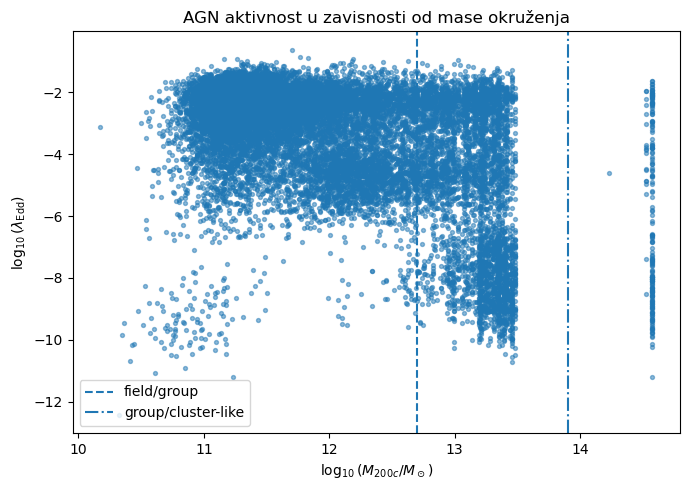

In [258]:
plot_data = clean.dropna(subset=["logM200c_parent", "log_lambda_edd"])

plt.figure(figsize=(7, 5))

plt.scatter(plot_data["logM200c_parent"],plot_data["log_lambda_edd"],s=8,alpha=0.5)
plt.axvline(np.log10(FIELD_GROUP_LIMIT), linestyle="--", label="field/group")
plt.axvline(np.log10(GROUP_CLUSTER_LIMIT), linestyle="-.", label="group/cluster-like")
plt.xlabel(r"$\log_{10}(M_{200c}/M_\odot)$")
plt.ylabel(r"$\log_{10}(\lambda_{\rm Edd})$")
plt.title("AGN aktivnost u zavisnosti od mase okruženja")

plt.legend()
plt.tight_layout()
plt.savefig("lambda_edd_vs_m200c.png", dpi=200)
plt.show()

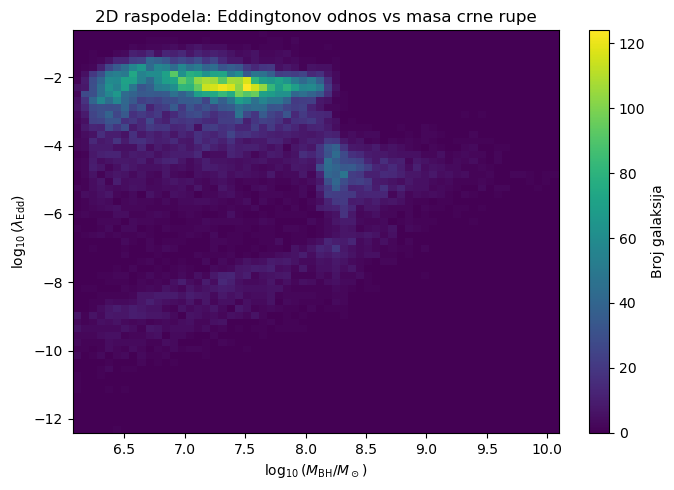

In [262]:
plot_data = clean.dropna(subset=["logMBH", "log_lambda_edd"])

plt.figure(figsize=(7, 5))

plt.hist2d(plot_data["logMBH"],plot_data["log_lambda_edd"],bins=60)

plt.xlabel(r"$\log_{10}(M_{\rm BH}/M_\odot)$")
plt.ylabel(r"$\log_{10}(\lambda_{\rm Edd})$")
plt.title("2D raspodela: Eddingtonov odnos vs masa crne rupe")

plt.colorbar(label="Broj galaksija")

plt.tight_layout()
plt.show()

In [180]:
#import numpy as np
#import matplotlib.pyplot as plt

#def plot_hist(data, name, bins=50, logx=False, logy=False):
#    data = np.asarray(data).ravel()
#    data = data[np.isfinite(data)]

#    if logx:
#        data = data[data > 0]
#        data = np.log10(data)
#        xlabel = f"log10({name})"
#    else:
#        xlabel = name

#    plt.figure(figsize=(7, 4))
#    plt.hist(data, bins=bins, edgecolor="black", alpha=0.7)

#    if logy:
#        plt.yscale("log")

#   plt.xlabel(xlabel)
#    plt.ylabel("Broj objekata")
#    plt.title(f"Histogram: {name}")
#    plt.tight_layout()
#    plt.show()

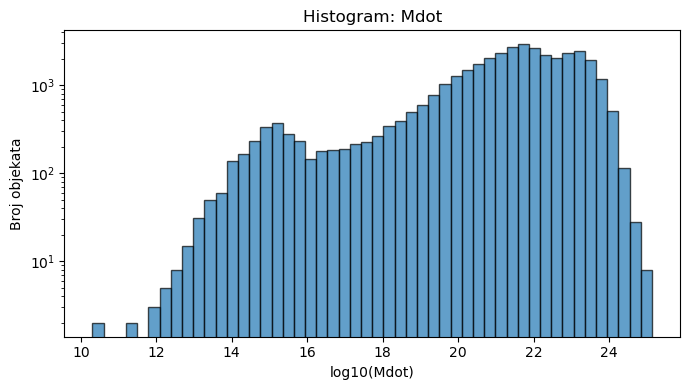

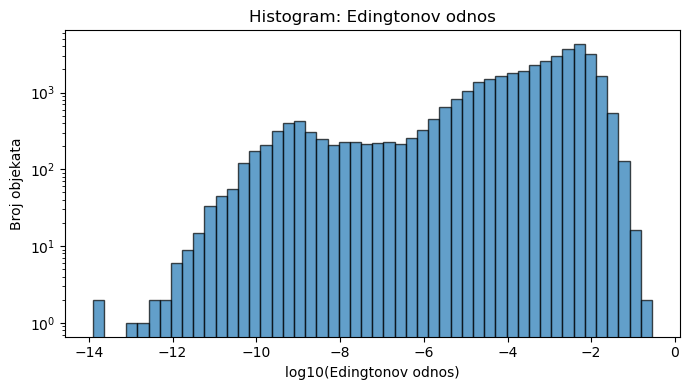

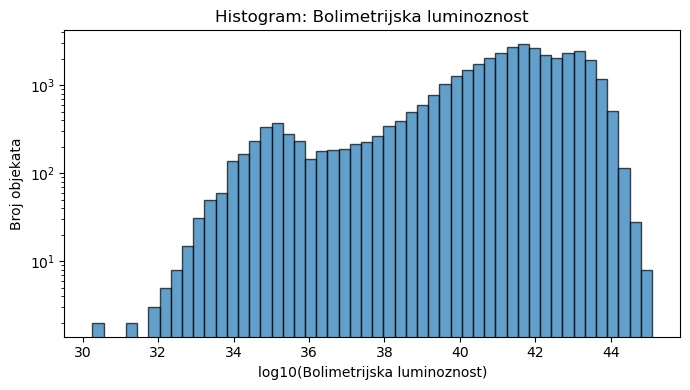

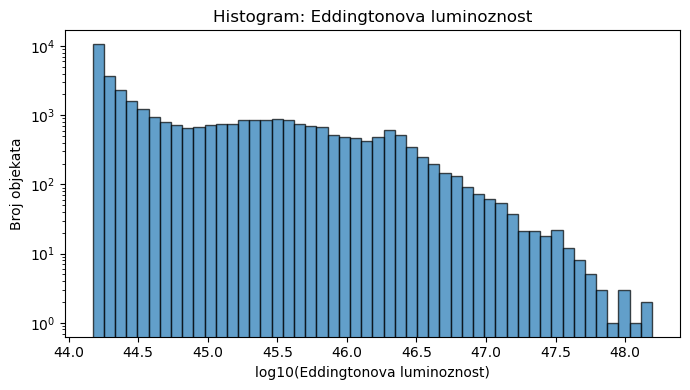

In [138]:
#gas_mass = SubhaloMassType[:, 0]
#dm_mass = SubhaloMassType[:, 1]
#stellar_mass = SubhaloMassType[:, 4]
#bh_mass = SubhaloMassType[:, 5]


#plot_hist(gas_mass, "Gas Mass", logx=True, logy=True)
#plot_hist(dm_mass, "Dark Matter Mass", logx=True, logy=True)
#plot_hist(stellar_mass, "Stellar Mass", logx=True, logy=True)
#plot_hist(bh_mass, "Black Hole Mass", logx=True, logy=True)

#plot_hist(Mdot_g_s,"Mdot" , logx=True, logy=True)
#plot_hist(lambda_edd[mask_bh],"Edingtonov odnos",logx=True, logy=True)
#plot_hist(L_bol,"Bolimetrijska luminoznost",logx=True, logy=True)
#plot_hist(L_edd,"Eddingtonova luminoznost",logx=True, logy=True)

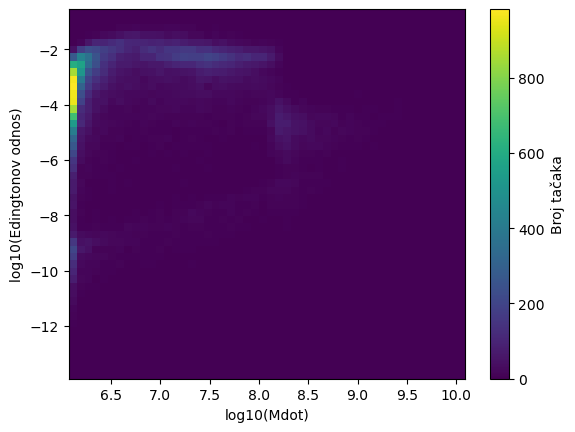

In [264]:
#import numpy as np
#import matplotlib.pyplot as plt


x = np.array(MBH)
y = np.array(lambda_edd)

mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)

plt.hist2d(np.log10(x[mask]), np.log10(y[mask]), bins=50)

plt.xlabel("log10(MBH)")
plt.ylabel("log10(Edingtonov odnos)")
plt.colorbar(label="Broj tačaka")
plt.show()

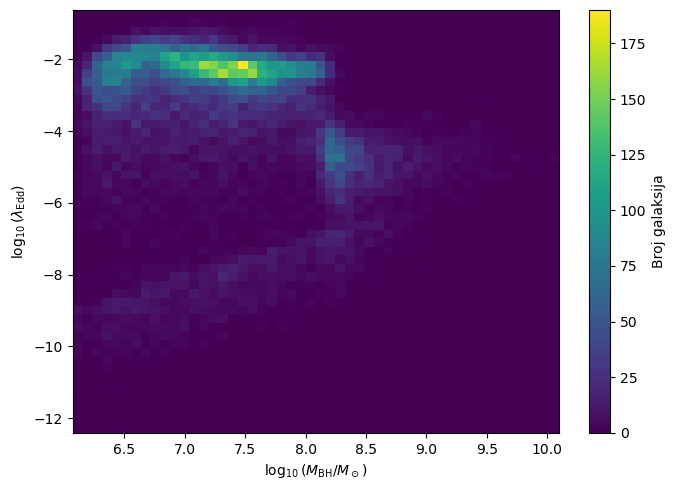

In [266]:
#ocisceni podaci
plot_data = clean.dropna(subset=["logMBH", "log_lambda_edd"])

plt.figure(figsize=(7, 5))

plt.hist2d(plot_data["logMBH"],plot_data["log_lambda_edd"],bins=50)

plt.xlabel(r"$\log_{10}(M_{\rm BH}/M_\odot)$")
plt.ylabel(r"$\log_{10}(\lambda_{\rm Edd})$")
plt.colorbar(label="Broj galaksija")

plt.tight_layout()
plt.show()

In [ ]:
plot_data = clean.dropna(subset=["logMBH", "log_lambda_edd"])

plt.figure(figsize=(7, 5))

plt.hist2d(plot_data["logMBH"],plot_data["log_lambda_edd"],bins=50)

plt.xlabel(r"$\log_{10}(M_{\rm BH}/M_\odot)$")
plt.ylabel(r"$\log_{10}(\lambda_{\rm Edd})$")
plt.colorbar(label="Broj galaksija")

plt.tight_layout()
plt.show()

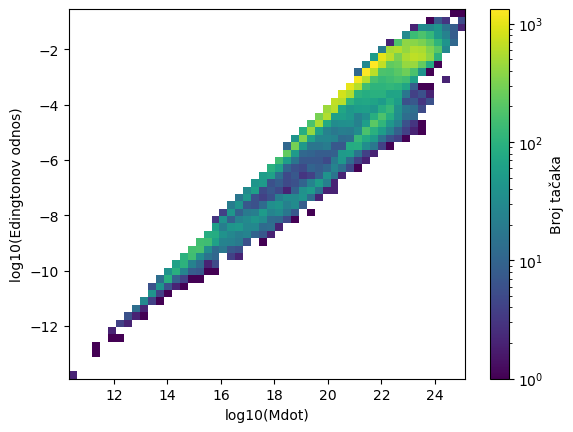

In [169]:
#Ovo nije dobro
#import numpy as np
#import matplotlib.pyplot as plt
#from matplotlib.colors import LogNorm

#x = np.array(Mdot_g_s)
#y = np.array(lambda_edd)

#mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)

#plt.hist2d(
#    np.log10(x[mask]),
#    np.log10(y[mask]),
#    bins=50,
#    norm=LogNorm()
#)

#plt.xlabel("log10(Mdot)")
#plt.ylabel("log10(Edingtonov odnos)")
#plt.colorbar(label="Broj tačaka")
#plt.show()

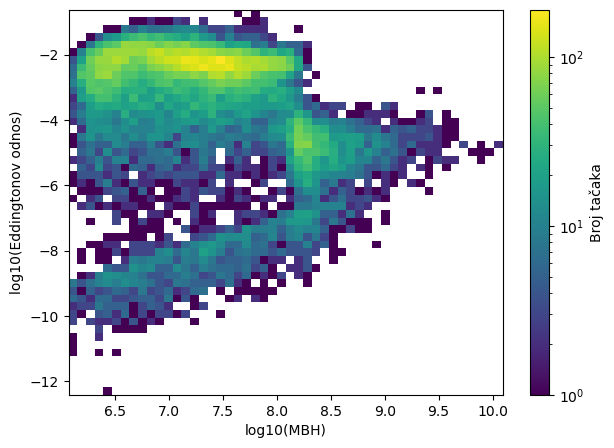

In [268]:
#ocisceni podaci
x = np.array(clean["MBH"])
y = np.array(clean["lambda_edd"])

mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)

plt.figure(figsize=(7, 5))

plt.hist2d(
    np.log10(x[mask]),
    np.log10(y[mask]),
    bins=50,
    norm=LogNorm()
)

plt.xlabel("log10(MBH)")
plt.ylabel("log10(Eddingtonov odnos)")
plt.colorbar(label="Broj tačaka")
plt.show()

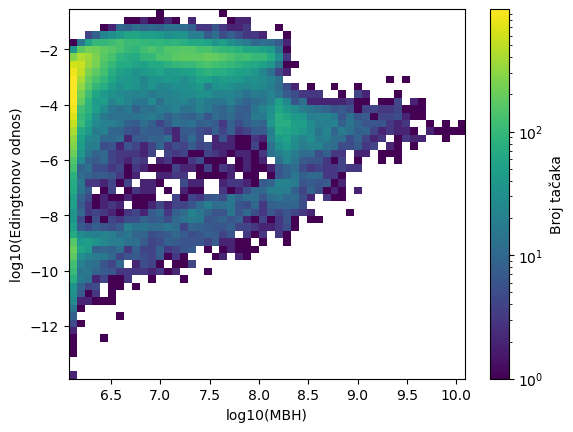

In [178]:
#Neocisceni podaci
#x = np.array(MBH)
#y = np.array(lambda_edd)

#mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)

#plt.hist2d(
#    np.log10(x[mask]),
#    np.log10(y[mask]),
#    bins=50,
#    norm=LogNorm()
#)

#plt.xlabel("log10(MBH)")
#plt.ylabel("log10(Edingtonov odnos)")
#plt.colorbar(label="Broj tačaka")
#plt.show()


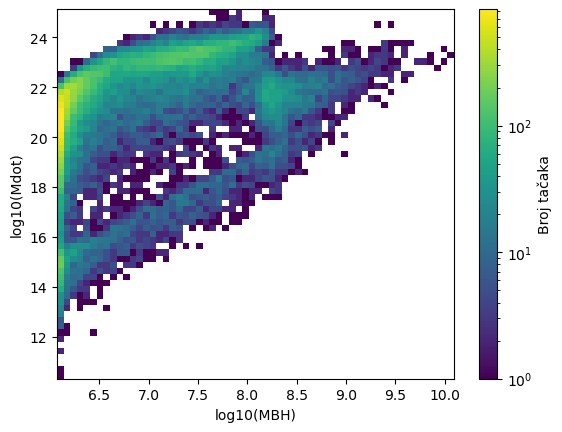

In [182]:
#import numpy as np
#import matplotlib.pyplot as plt
#from matplotlib.colors import LogNorm

#x = np.array(MBH)
#y = np.array(Mdot_g_s)

#mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)

#plt.hist2d(
#    np.log10(x[mask]),
#    np.log10(y[mask]),
#    bins=60,
#    norm=LogNorm()
#)

#plt.xlabel("log10(MBH)")
#plt.ylabel("log10(Mdot)")
#plt.colorbar(label="Broj tačaka")
#plt.show()

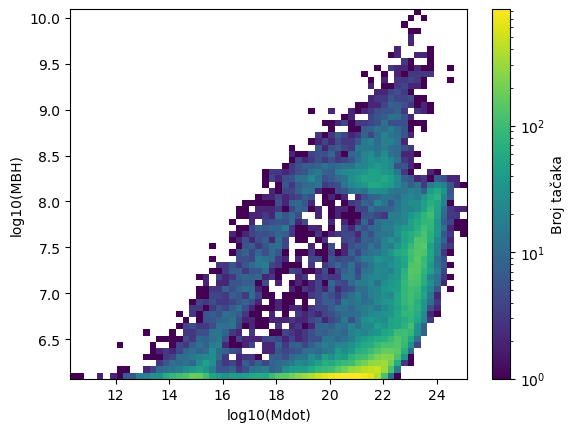

In [184]:
#x = np.array(Mdot_g_s)
#y = np.array(MBH)

#mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)

#plt.hist2d(
#    np.log10(x[mask]),
#    np.log10(y[mask]),
#    bins=60,
#    norm=LogNorm()
#)

#plt.xlabel("log10(Mdot)")
#plt.ylabel("log10(MBH)")
#plt.colorbar(label="Broj tačaka")
#plt.show()